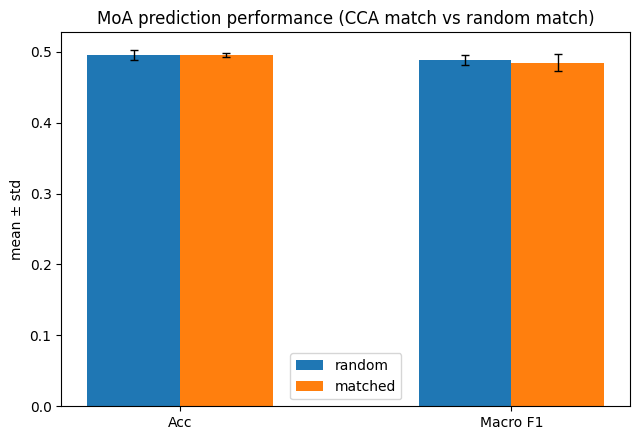

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

matched_path = "CCA_matched.csv"
random_path  = "CCA_random.csv"

def read_stats(path):
    df = pd.read_csv(path)
    acc = pd.to_numeric(df["test/acc"], errors="coerce").dropna().to_numpy()
    f1  = pd.to_numeric(df["test/f1"],  errors="coerce").dropna().to_numpy()
    return {
        "acc_mean": acc.mean(),
        "acc_std":  acc.std(ddof=1),
        "f1_mean":  f1.mean(),
        "f1_std":   f1.std(ddof=1),
    }

s_m = read_stats(matched_path)
s_r = read_stats(random_path)

metrics = ["Acc", "Macro F1"]
x = np.arange(len(metrics))
w = 0.28  # 막대 폭

matched_means = [s_m["acc_mean"], s_m["f1_mean"]]
matched_stds  = [s_m["acc_std"],  s_m["f1_std"]]
random_means  = [s_r["acc_mean"], s_r["f1_mean"]]
random_stds   = [s_r["acc_std"],  s_r["f1_std"]]

plt.figure(figsize=(6.5, 4.5))
err_kw = dict(capsize=3, elinewidth=1, capthick=1)

plt.bar(x - w/2, random_means, width=w, yerr=matched_stds, label="random", error_kw=err_kw)
plt.bar(x + w/2, matched_means,  width=w, yerr=random_stds,  label="matched",  error_kw=err_kw)

plt.xticks(x, metrics)
plt.ylabel("mean ± std")
plt.title("MoA prediction performance (CCA match vs random match)")
plt.legend()
plt.tight_layout()
plt.show()